# **Mission of the classification notebook**

You have joined a space-biology team studying how *Arabidopsis thaliana* roots adapt to life aboard the International Space Station (ISS). The [CARA experiment (OSD-120)](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120), led by Anna-Lisa Paul and Robert Ferl, grew Arabidopsis seedlings in spaceflight (FLT) and on matched ground controls (GC), then RNA-sequenced their roots to capture how thousands of genes respond to the spaceflight environment.

Your goal is to determine whether there are [biological pathways](https://en.wikipedia.org/wiki/Biological_pathway) in the root transcriptome that are responding to conditions in space, because if so, there may be molecular markers that distinguish a spaceflight-grown root from a ground-grown one. But first you must determine if there is any association at all between the RNA-seq gene expression data and the growth condition of each plant. Your mission is to evaluate the use of random forest and single-layer perceptron classification algorithms to determine whether the genes expressed in root tissue are predictive of the conditions the plants experienced. You are also encouraged to try the [logistic regression algorithm](https://en.wikipedia.org/wiki/Logistic_regression) for the same.


# Set up the toolbox

In this notebook we read the CARA data directly from the NASA OSDR public download service and use scikit-learn for the classification algorithms. The cell below imports everything we need: `pandas`/`numpy` for data handling, and the scikit-learn classes for splitting data, training models, and scoring them.


In [1]:
# import the python modules we will use throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree


In [2]:
# the OSDR public download service: build a URL for any file in study OSD-120 (CARA)
OSDR_BASE = ("https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/"
             "download?source=datamanager&file=")

def osdr_url(filename):
    return OSDR_BASE + filename


In [3]:
# helper functions for loading and reshaping the CARA root RNA-seq data

def condition_from_sample(sample_name):
    """Return 'FLT' (spaceflight) or 'GC' (ground control) from a CARA sample column name."""
    if "FLT" in sample_name:
        return "FLT"
    if "GC" in sample_name:
        return "GC"
    return None

def light_from_sample(sample_name):
    """Return 'light' or 'dark' growth treatment from a CARA sample column name."""
    if "Alight" in sample_name:
        return "light"
    if "dark" in sample_name:
        return "dark"
    return None

def filter_by_cv(counts, threshold):
    """Dimensionality reduction: keep only genes whose coefficient of variation
    (std / mean across samples) exceeds the threshold. This removes low-variance
    genes that carry little signal for classification."""
    mean = counts.mean(axis=1)
    std = counts.std(axis=1)
    cv = std / mean.replace(0, np.nan)
    keep = cv[cv > threshold].index
    return counts.loc[keep]


# Read in the data

After setting up the toolbox, we read in the CARA root RNA-seq data from the NASA OSDR space-biology data repository. In this notebook we use the normalized transcriptomic counts from **OSD-120** (24,740 genes across 36 root samples: 18 spaceflight and 18 ground control).

After reading in the data from OSDR, we will reduce the dimensions of the RNA-seq data to include only those genes whose [coefficient of variation](https://en.wikipedia.org/wiki/Coefficient_of_variation) is greater than a threshold. This is a form of [dimensionality reduction](https://en.wikipedia.org/wiki/Dimensionality_reduction) that will remove some noise from the gene expression so our classification algorithms can focus on the signal.


In [4]:
# define dictionaries for data and metadata
data = dict()
metadata = dict()


In [5]:
# read in the sample condition table (GROUND vs FLIGHT labels) from OSD-120
metadata['120'] = pd.read_csv(
    osdr_url('GLDS-120_rna_seq_SampleTable_GLbulkRNAseq.csv'), index_col=0)
print('num samples:', len(metadata['120']))
metadata['120'].head()


num samples: 36


,condition
Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Col.0...Ground.Control...Light.Treatment
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Col.0...Ground.Control...Light.Treatment
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Wassilewskija.ecotype...Ground.Control...Light...
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Wassilewskija.ecotype...Ground.Control...Light...
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Wassilewskija.ecotype...Ground.Control...Light...


In [6]:
# build the spaceflight (FLT) vs ground-control (GC) label for every root sample
data['condition'] = pd.read_csv(
    osdr_url('GLDS-120_rna_seq_Normalized_Counts_GLbulkRNAseq.csv'),
    index_col=0, nrows=0)
sample_names = list(data['condition'].columns)
sample_condition = {s: condition_from_sample(s) for s in sample_names}
print('num samples: ', len(sample_names))
print('FLT (spaceflight):', sum(v == 'FLT' for v in sample_condition.values()))
print('GC  (ground):     ', sum(v == 'GC' for v in sample_condition.values()))
pd.Series(sample_condition, name='condition').head()


num samples:  36
FLT (spaceflight): 18
GC  (ground):      18


Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13    GC
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13    GC
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13       GC
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13       GC
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13       GC
Name: condition, dtype: object

In [7]:
# build a second label: the light vs dark growth treatment for every root sample
sample_light = {s: light_from_sample(s) for s in sample_names}
print('num samples: ', len(sample_names))
print('light:', sum(v == 'light' for v in sample_light.values()))
print('dark: ', sum(v == 'dark' for v in sample_light.values()))
pd.Series(sample_light, name='light_treatment').head()


num samples:  36
light: 18
dark:  18


Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13    light
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13    light
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13       light
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13       light
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13       light
Name: light_treatment, dtype: object

In [8]:
# read in the normalized transcriptomic counts (genes x samples) from OSD-120
data['120-normalized'] = pd.read_csv(
    osdr_url('GLDS-120_rna_seq_Normalized_Counts_GLbulkRNAseq.csv'), index_col=0)
print('full RNA-seq shape (genes x samples):', data['120-normalized'].shape)
data['120-normalized'].head()


full RNA-seq shape (genes x samples): (24740, 36)


,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01010,114.904131,138.527368,120.022494,264.937105,191.422936,242.517040,412.253673,210.840135,144.668736,201.744019,...,424.847210,147.983322,277.194348,115.874562,309.806447,320.963807,398.109857,104.633344,85.672000,105.632330
AT1G01020,673.515535,621.793455,645.936090,439.201986,522.399305,748.214534,537.977432,739.297948,656.648675,627.933477,...,463.448392,713.731341,961.798409,496.336366,569.696041,454.003757,581.384441,749.912117,688.502249,559.374814
AT1G01030,94.043792,94.223868,65.271628,103.706224,86.287958,103.357911,189.930809,141.967726,81.612611,110.981125,...,49.957938,80.945443,161.394188,43.761590,105.958171,136.696201,96.310749,182.954416,249.215970,123.892672
AT1G01040,164.879084,94.035143,238.621873,132.559195,182.120176,175.679477,205.565473,131.052912,171.811433,134.112724,...,83.333634,156.572361,101.033035,234.971130,209.744502,350.823340,155.615105,161.055119,189.724432,108.131266
AT1G01046,0.000000,0.000000,0.000000,0.000000,5.052491,0.000000,2.427154,0.000000,0.829751,0.000000,...,1.393093,0.000000,0.000000,0.000000,0.000000,0.000000,0.988599,0.000000,0.000000,1.004718


In [9]:
# reduce dimensions: keep only genes with a high coefficient of variation across samples
rna_seq = filter_by_cv(data['120-normalized'], threshold=1.0)
print('rna_seq data shape (genes x samples): ', rna_seq.shape)


rna_seq data shape (genes x samples):  (6373, 36)


**QUESTIONS**

1. How many genes were in the RNA-seq dataset before filtering on the coefficient of variation? After filtering?

2. How many root samples are labelled as spaceflight (FLT)? As ground control (GC)?

3. How many samples were grown under the light treatment? Under the dark treatment?


# Predict spaceflight vs ground control from RNA-seq (gene expression) data

In this first task we ask whether the root transcriptome alone can tell us where a plant was grown: aboard the ISS (spaceflight, FLT) or on the ground (GC). We will use the high-variance genes as features and the FLT/GC label as the target.


## Prepare the data for the algorithms

In [10]:
# assemble the feature matrix X (samples as rows, genes as columns) and target y (FLT vs GC)
X = rna_seq.transpose()
y = np.array([1 if sample_condition[s] == 'FLT' else 0 for s in X.index])
print('class balance (0=GC, 1=FLT):', dict(zip(*np.unique(y, return_counts=True))))
X.head()


class balance (0=GC, 1=FLT): {np.int64(0): np.int64(18), np.int64(1): np.int64(18)}


,AT1G01046,AT1G01060,AT1G01120,AT1G01150,AT1G01183,AT1G01190,AT1G01305,AT1G01355,AT1G01390,AT1G01420,...,ATMG01110,ATMG01140,ATMG01180,ATMG01250,ATMG01260,ATMG01290,ATMG01310,ATMG01400,ATMG09450,ATMG09730
Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,0.000000,617.440717,32.639462,0.000000,1.052151,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,0.920622,0.00000,0.936828,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,0.000000,705.549092,16.693466,7.262507,0.000000,17.965330,2.53038,0.000000,1.952293,4.960501,...,0.0,0.000000,0.61826,2.483320,0.000000,0.00000,0.000000,0.000000,1.228651,1.228651
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,0.000000,634.669145,2.787080,0.000000,0.000000,0.000000,0.00000,3.890977,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,1.894255,0.00000,0.000000,3.943631,1.195977,1.195977
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,0.000000,401.882409,38.852513,1.797644,1.006704,0.999323,0.00000,1.027140,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.993239,1.97918,0.990537,1.978876,1.021675,1.021675
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,5.052491,612.499130,14.198386,0.000000,0.000000,1.795925,0.00000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,6.762302,1.978107,0.00000,2.189806,2.338994,0.000000,0.000000


In [11]:
# our feature columns are gene IDs (Arabidopsis AGI loci) and our rows are samples
print('number of samples (rows):', X.shape[0])
print('number of gene features (cols):', X.shape[1])
print('first few gene features:', list(X.columns[:5]))


number of samples (rows): 36
number of gene features (cols): 6373
first few gene features: ['AT1G01046', 'AT1G01060', 'AT1G01120', 'AT1G01150', 'AT1G01183']


In [12]:
# y encodes the growth condition: 1 = spaceflight (FLT), 0 = ground control (GC)
print('target y:', list(y))


target y: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]


In [13]:
# X already holds the gene-expression features (one row per sample)
print('feature matrix X shape:', X.shape)


feature matrix X shape: (36, 6373)


In [14]:
# split up data between training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [15]:
# show the dimensions of the training and testing data
print('X train: ', X_train.shape)
print('y train: ', len(y_train))
print('X test: ', X_test.shape)
print('y test: ', len(y_test))

X train:  (28, 6373)
y train:  28
X test:  (8, 6373)
y test:  8


**QUESTIONS**

1. How many samples are used for training?

2. How many samples are used for testing?

3. Based on the number of samples used for testing, what are the possible values for the testing accuracy?

## Build a random forest model to predict spaceflight vs ground from gene expression


In [16]:
# run random forest classification on X, y

clf = RandomForestClassifier(max_depth=8, random_state=23)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("test accuracy:", test_acc)


train accuracy: 1.0
test accuracy: 0.75


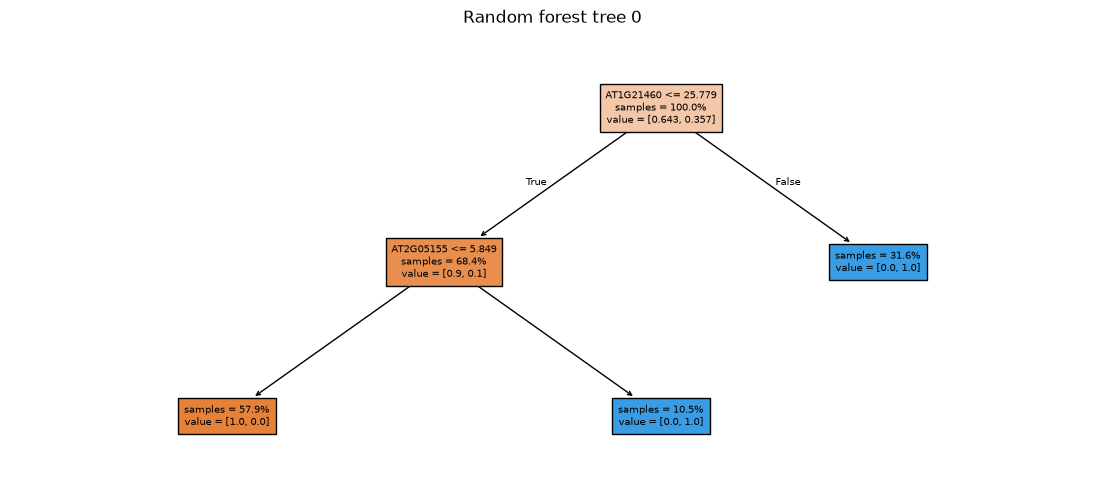

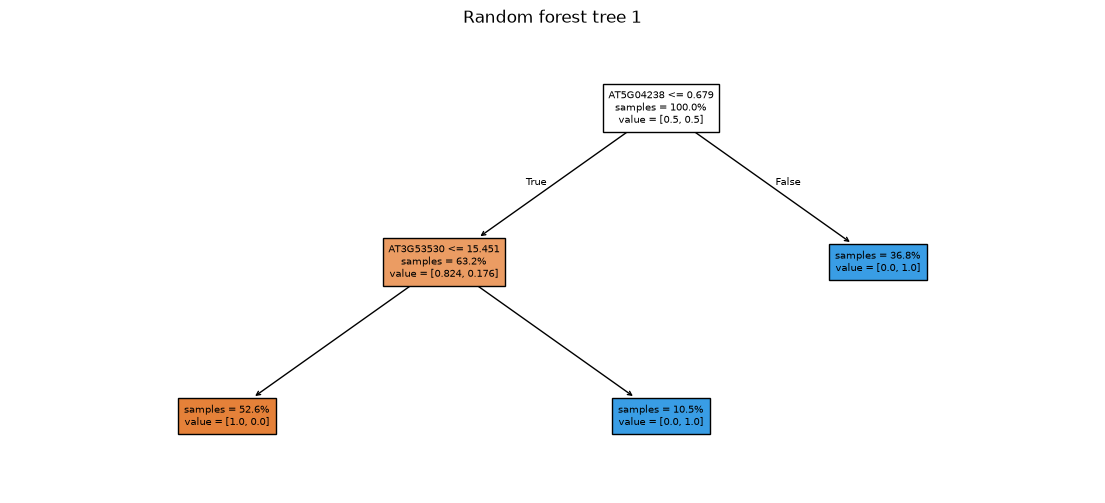

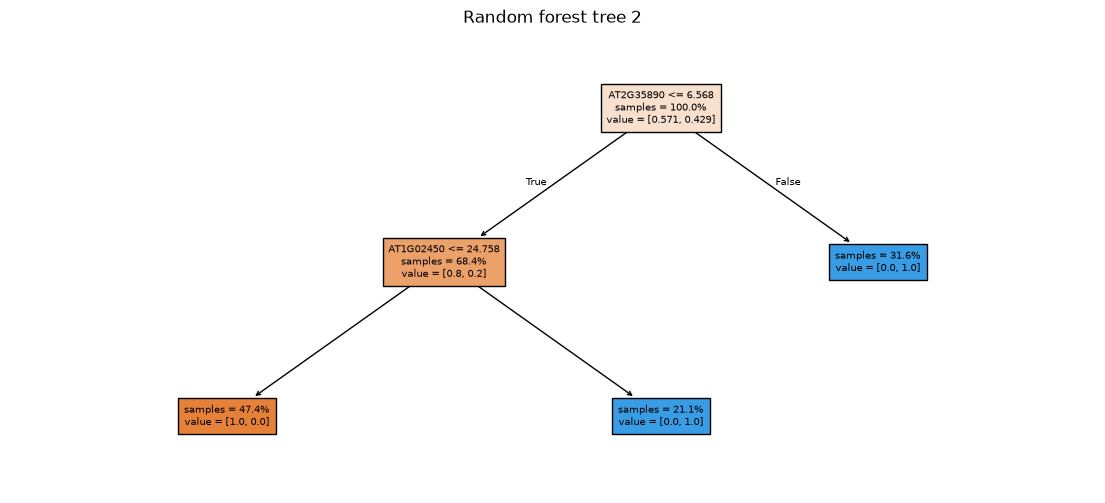

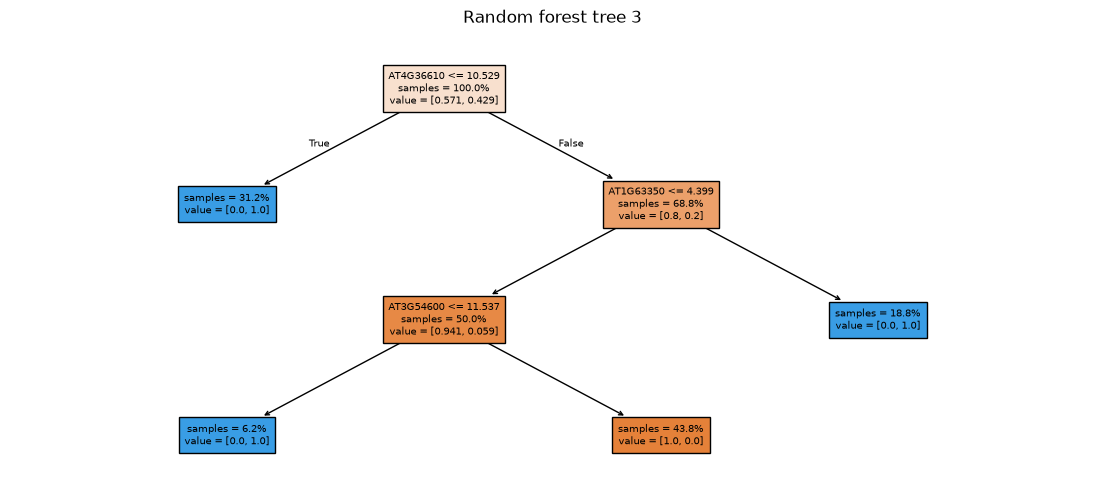

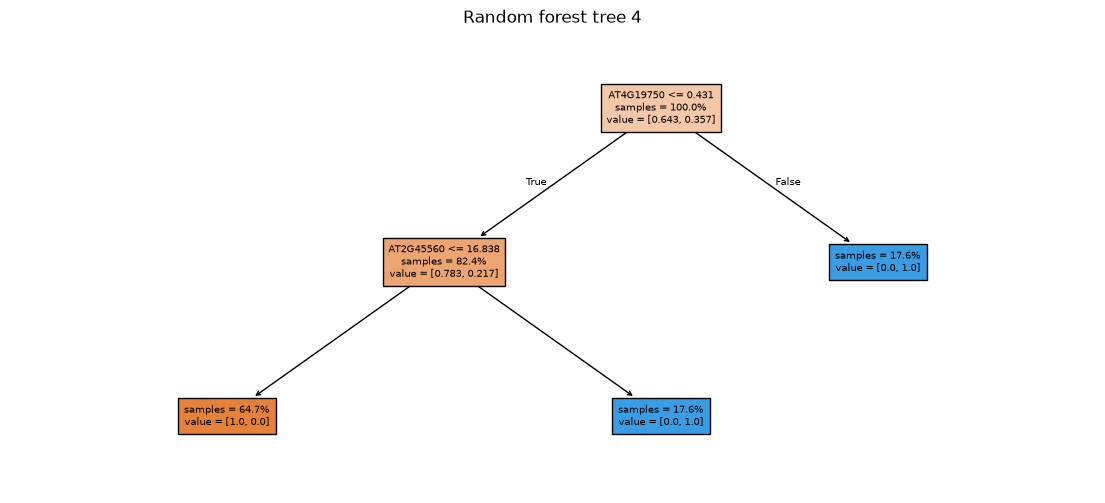

In [17]:
# visualize the first few decision trees in the random forest
num_trees = 5
for i in range(num_trees):
    tree = clf.estimators_[i]
    plt.figure(figsize=(14, 6))
    plot_tree(tree,
              feature_names=list(X_train.columns),
              filled=True,
              impurity=False,
              proportion=True,
              fontsize=7)
    plt.title(f"Random forest tree {i}")
    plt.show()


In [18]:
# now create a confusion matrix
y_pred = clf.predict(X_test)
confusion_matrix(y_test, y_pred)


array([[4, 0],
       [2, 2]])

**QUESTIONS**

1. What is the training accuracy of the random forest model? Test accuracy?

2. Which genes are used in the decision trees of the random forest model?

3. According to the confusion matrix, how many ground-control (GC) samples were correctly classified? How many spaceflight (FLT)? How many GC samples were confused with FLT samples?


## Build a single-layer perceptron model that predicts spaceflight vs ground from gene expression


In [19]:
# run single-layer perceptron classification on X, y

clf = Perceptron(tol=1e-3, random_state=0)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("test accuracy:", test_acc)

print('overall score: ', clf.score(X, y))


train accuracy: 1.0
test accuracy: 0.75
overall score:  0.9444444444444444


**QUESTIONS**

1. What is the training accuracy of the SLP model?

2. What is the test accuracy of the SLP model?

3. What might explain the discrepancy between the training and testing accuracy?

## BONUS: Build a logistic regression model that predicts spaceflight vs ground from gene expression


In [20]:
# now run logistic regression classification on X, y

clf = LogisticRegression(random_state=23, max_iter=1000)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("test accuracy:", test_acc)


train accuracy: 1.0
test accuracy: 0.75


**QUESTIONS**

1. What is the training accuracy of the logistic regression model?

2. What is the test accuracy of the logistic regression model?

3. Which model has a better test accuracy for predicting spaceflight vs ground from gene expression -- the random forest model, the SLP model, or the logistic regression model?


# Predict light vs dark growth treatment from RNA-seq (gene expression)

For a second classification task we ask whether the root transcriptome can distinguish the light growth treatment from the dark growth treatment. We reuse the same high-variance gene features, but now the target is the light/dark label of each sample.


## Prepare the data for the algorithms

In [21]:
# reduce dimensions again: keep only the high coefficient-of-variation genes
rna_seq = filter_by_cv(data['120-normalized'], threshold=1.0)
print('rna_seq data shape (genes x samples): ', rna_seq.shape)


rna_seq data shape (genes x samples):  (6373, 36)


In [22]:
# assemble the feature matrix and the light vs dark target from the same root samples
X = rna_seq.transpose()
light_samples = [s for s in X.index if sample_light[s] == 'light']
dark_samples = [s for s in X.index if sample_light[s] == 'dark']
print('light samples:', len(light_samples))
print('dark samples: ', len(dark_samples))


light samples: 18
dark samples:  18


In [23]:
# X holds gene-expression features (one row per sample); columns are gene IDs
print('feature matrix X shape:', X.shape)
print('first few gene features:', list(X.columns[:5]))


feature matrix X shape: (36, 6373)
first few gene features: ['AT1G01046', 'AT1G01060', 'AT1G01120', 'AT1G01150', 'AT1G01183']


In [24]:
# the light/dark treatment label for each sample
pd.Series({s: sample_light[s] for s in X.index}, name='light_treatment')


Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13          light
Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13          light
Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13             light
Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13             light
Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13             light
Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13     light
Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13     light
Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13     light
Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13             dark
Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13             dark
Atha_Col-0_root_GC_dark_Rep3_GSM2493770_Day13             dark
Atha_Ws_root_GC_dark_Rep1_GSM2493771_Day13                dark
Atha_Ws_root_GC_dark_Rep2_GSM2493772_Day13                dark
Atha_Ws_root_GC_dark_Rep3_GSM2493773_Day13                dark
Atha_Col-0-PhyD_root_GC_dark_Rep1_GSM2493774_Day13        dark
Atha_Col-0-PhyD_root_GC_dark_Rep2_GSM2493775_Day13     

In [25]:
# create target array y of light (1) vs dark (0) treatment labels
y = np.array([1 if sample_light[s] == 'light' else 0 for s in X.index])
print('class balance (0=dark, 1=light):', dict(zip(*np.unique(y, return_counts=True))))
print('y = ', list(y))


class balance (0=dark, 1=light): {np.int64(0): np.int64(18), np.int64(1): np.int64(18)}
y =  [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


In [26]:
# X already holds the gene-expression features (one row per sample)
print('feature matrix X shape:', X.shape)


feature matrix X shape: (36, 6373)


In [27]:
# split up data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [28]:
# show the dimensions of the training and testing data
print('X train: ', X_train.shape)
print('y train: ', len(y_train))
print('X test: ', X_test.shape)
print('y test: ', len(y_test))

X train:  (28, 6373)
y train:  28
X test:  (8, 6373)
y test:  8


**QUESTIONS**

1. How many samples are used for training the model?

2. How many samples are used for testing the model?

3. Based on the number of samples for testing, what are the possible accuracy scores?

## Build a random forest model to predict light vs dark treatment from gene expression


In [29]:
# now run classification on X, y
max_depth=4
clf = RandomForestClassifier(max_depth=max_depth, random_state=23)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("test accuracy:", accuracy)

train accuracy: 1.0
test accuracy: 1.0


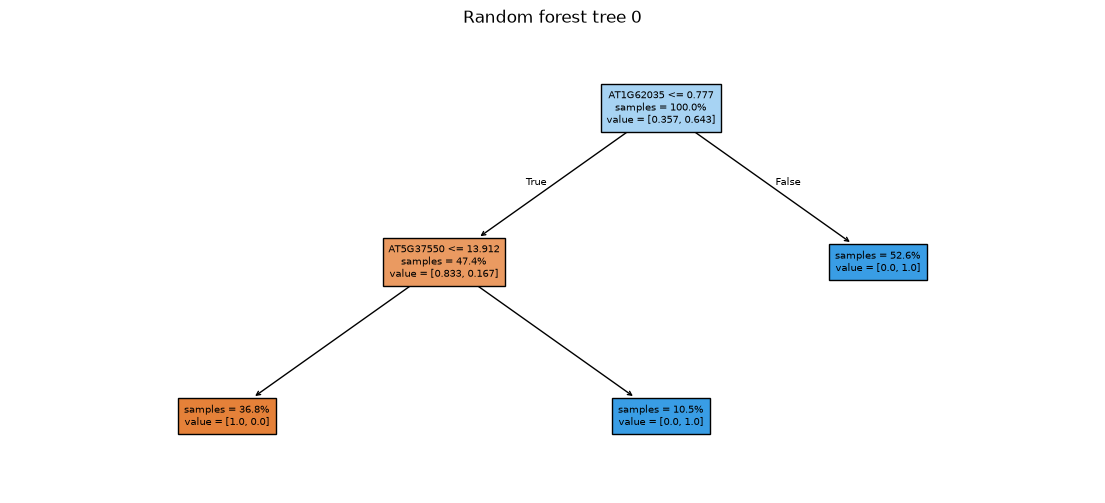

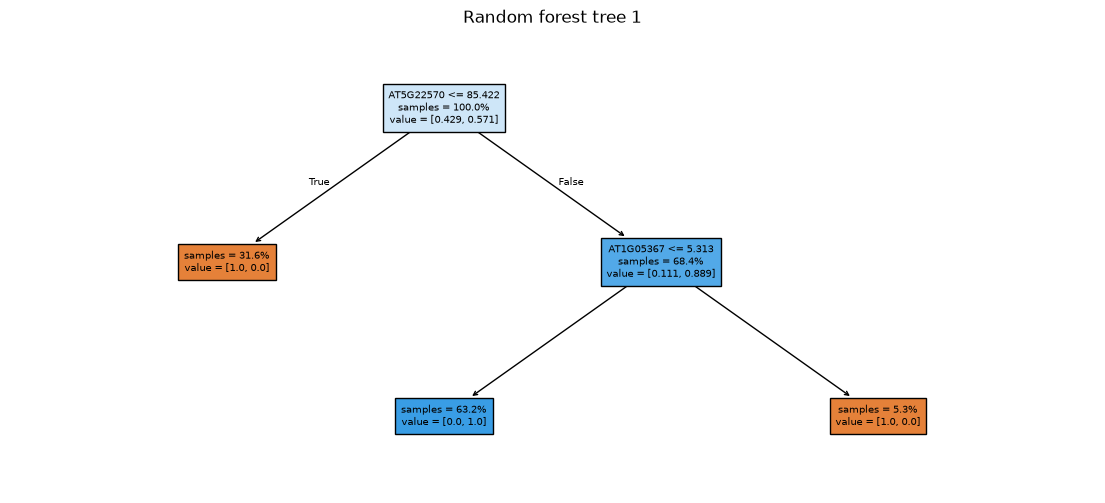

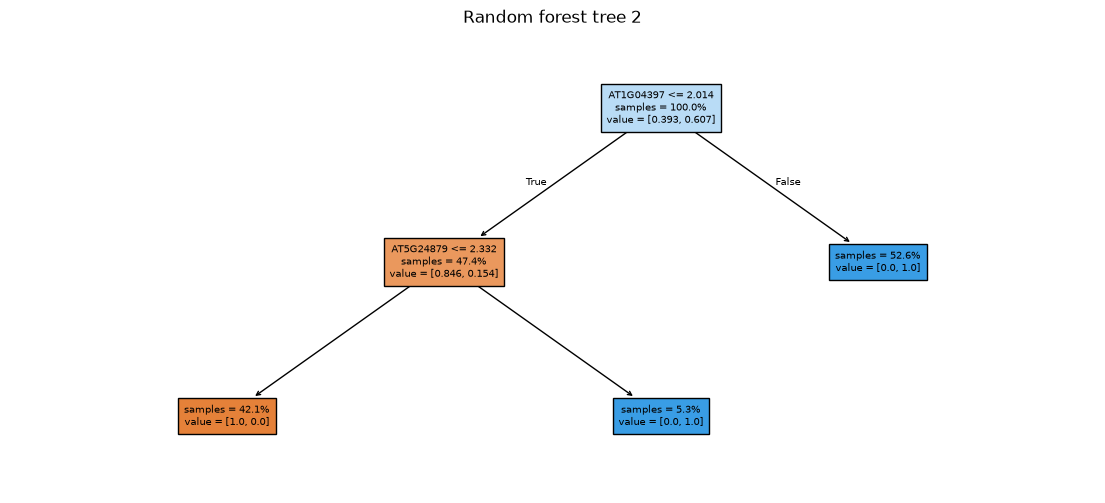

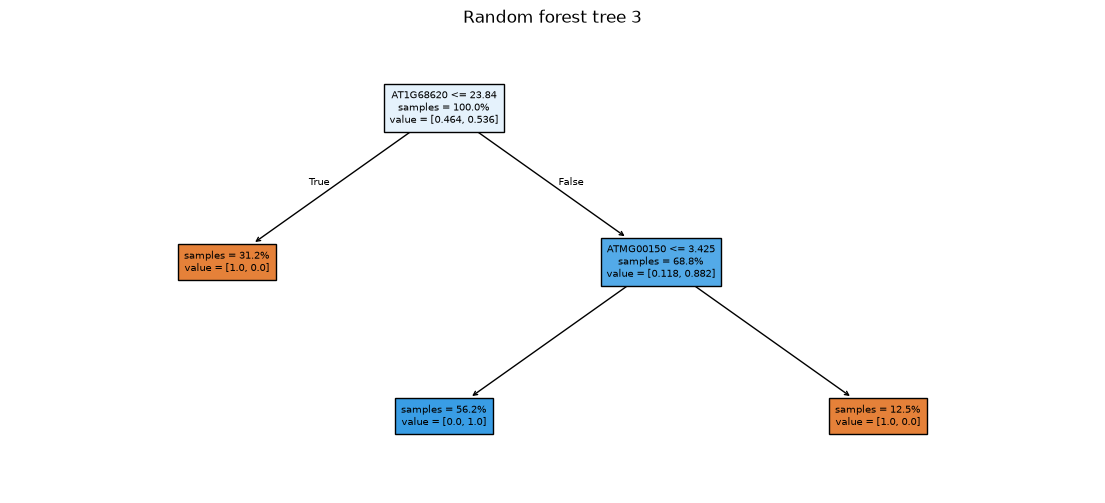

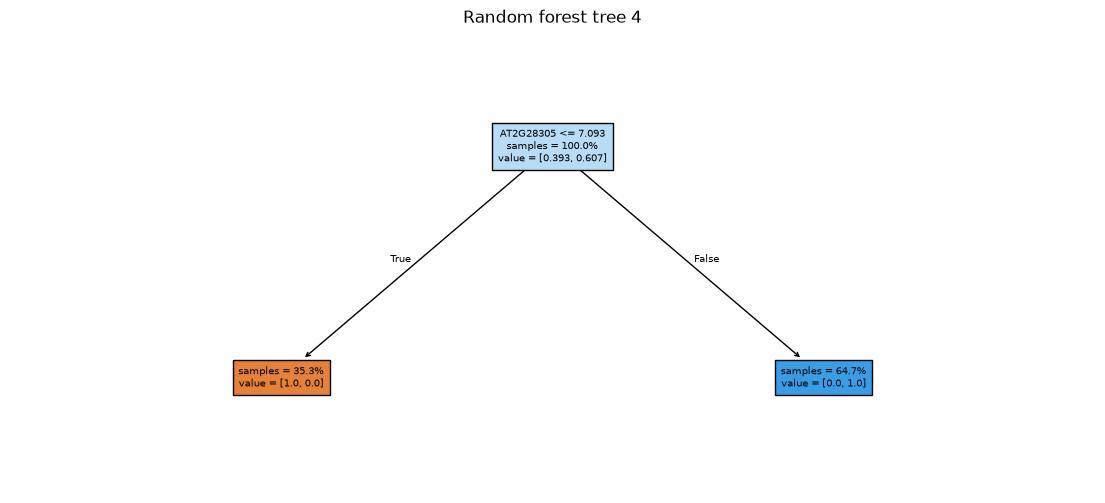

In [30]:
# visualize the first few decision trees / feature importance
num_trees = 5
for i in range(num_trees):
    tree = clf.estimators_[i]
    plt.figure(figsize=(14, 6))
    plot_tree(tree,
              feature_names=list(X_train.columns),
              filled=True,
              impurity=False,
              proportion=True,
              fontsize=7)
    plt.title(f"Random forest tree {i}")
    plt.show()


**QUESTIONS**

1. What is training accuracy of the random forest model?

2. What is the test accuracy of the random forest model?

3. Which genes are used in the decision trees of the random forest?

## BONUS: Build a logistic regression model to predict light vs dark treatment from gene expression


In [31]:
# now run classification on X, y

clf = LogisticRegression(random_state=23, max_iter=1000)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("test accuracy:", accuracy)


train accuracy: 1.0
test accuracy: 1.0


**QUESTIONS**

1. What is the training accuracy of the logistic regression model?

2. What is the test accuracy of the logistic regression model?

3. Which model has a better test accuracy for predicting light vs dark treatment from gene expression -- the random forest model or the logistic regression model?
